In [1]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
import utide
plt.rcParams.update({'font.size': 14}) 

deployment_num = [1,2,3,4,5]
sensor_spot = ["E", "C", "S"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

def tidal_ellipse(u,v,t,constituents = ['M2'], sensor = "S0",dep = "1",plotter = True):
 
    coef = utide.solve(t, u, v, lat=33.9, method="ols", conf_int="linear", constit=constituents)

    #With coefficients, we can reconstruct the tidal signal and plot the ellipses
    out = utide.reconstruct(t, coef)

    # Extract the fitted velocities
    u_fit = out.u
    v_fit = out.v
    if plotter == True:
        # Plotting the ellipse
        plt.figure(figsize=(6, 6))
        plt.plot(u_fit,v_fit, label='Reconstructed Tidal Ellipse')
        plt.axhline(0, color='black', lw=1, ls='--')
        plt.axvline(0, color='black', lw=1, ls='--')
        plt.xlabel("East Velocity (m/s)")
        plt.ylabel("North Velocity (m/s)")
        plt.title(f"Tidal Ellipse for {constituents[0]} - sensor {sensor} - Deployment {dep}")
        plt.axis('equal') # Crucial for seeing the true shape of the ellipse
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    #Remove tidal ellipse from original signal to get residuals
    u_residual = u - u_fit
    v_residual = v - v_fit

    return coef, out, pd.DataFrame({
        "U_residual": u_residual,
        "V_residual": v_residual
    })


c:\Users\lwlav\anaconda3\envs\boemenv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [2]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")  # Extract S0 or S1
            sensor_serial = sensor_location[1]
            if sensor_serial == "103071" or dep ==5:
                files = ["DepthAveragedCurrentVelocity","Time","DepthAveragedEastVelocity","DepthAveragedNorthVelocity","Echo1avg",
                         "SignificantWaveHeight","MeanPeriod","MeanDirection1",'StokesDriftDirection','StokesDriftMagnitude', 'Frequencies','Sedtime']
            else:
                files = ["DepthAveragedCurrentVelocity","Time","DepthAveragedEastVelocity","DepthAveragedNorthVelocity", "Vertavg",
                         "SignificantWaveHeight","MeanPeriod","MeanDirection1",'StokesDriftDirection','StokesDriftMagnitude', 'Frequencies','Sedtime']
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location[0]}_{dep}"] = waves
            

DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Echo1avg
SignificantWaveHeight
MeanPeriod
MeanDirection1
StokesDriftDirection
StokesDriftMagnitude
Frequencies
Sedtime
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
SignificantWaveHeight
MeanPeriod
MeanDirection1
StokesDriftDirection
StokesDriftMagnitude
Frequencies
Sedtime
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
SignificantWaveHeight
MeanPeriod
MeanDirection1
StokesDriftDirection
StokesDriftMagnitude
Frequencies
Sedtime
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Echo1avg
SignificantWaveHeight
MeanPeriod
MeanDirection1
StokesDriftDirection
StokesDriftMagnitude
Frequencies
Sedtime
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Vertavg
SignificantWaveHeight
MeanPeriod
MeanDirection1
StokesDriftDirection
StokesDriftMag

In [ ]:
###Low pass filter at 48hours to get subtidal flows
from spectral_sediment import despiker
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0, S1, E1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            coef, out, residuals = tidal_ellipse(waves["DepthAveragedEastVelocity"].values.squeeze(), 
                                              waves["DepthAveragedNorthVelocity"].values.squeeze(), 
                                              waves["Time"].values.squeeze(), 
                                              constituents=['M2'], 
                                              sensor=sensor_location, 
                                              dep=dep,
                                              plotter=False)
            if sensor_location == "E1" or dep == 5:
                waves['Echo1avg'] = despiker(despiker(waves['Echo1avg'], 3)[0], 3)[0]  # Despike Echo1avg with a threshold of 3
            if (sensor_location == "S0" and dep != 5) or (sensor_location == "S1" and dep != 5):
                waves['Vertavg'] = despiker(despiker(waves['Vertavg'], 3)[0], 3)[0]  # Despike Vertavg with a threshold of 3
            waves['Tide_Residual_u'] = coef.umean
            waves['Tide_Residual_v'] = coef.vmean
            waves['MajorTidalAxis'] = coef['Lsmaj']
            waves['MinorTidalAxis'] = coef['Lsmin']
            waves['Uvel'] = out.u
            waves['Vvel'] = out.v
            waves['Theta'] = coef['theta']
            waves['Eccentricity'] = np.sqrt(1 - (coef['Lsmin'] / coef['Lsmaj'])**2)
            waves['Phase'] = coef
            globals()[f"waves_{sensor_location}_{dep}"] = waves


Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... 

In [4]:
import tabulate

#Create a few tables summarizing tidal spatial and temporal variability across deployments and sensors.
#South over East per deployment 

SvE = [["Deployment", 1,2,3,4],
        ["Locations", "S1/E1", "S1/E1", "S0/E0", "S1/E1"],
        ["Major Axis Difference (%)", (waves_S1_1["MajorTidalAxis"]/waves_E1_1["MajorTidalAxis"])[0],
         (waves_S1_2["MajorTidalAxis"]/waves_E1_2["MajorTidalAxis"])[0],
         (waves_S0_3["MajorTidalAxis"]/waves_E0_3["MajorTidalAxis"])[0],
         (waves_S1_4["MajorTidalAxis"]/waves_E1_4["MajorTidalAxis"])[0]],
        ["Minor Axis Difference (%)", (waves_S1_1["MinorTidalAxis"]/waves_E1_1["MinorTidalAxis"])[0],
         (waves_S1_2["MinorTidalAxis"]/waves_E1_2["MinorTidalAxis"])[0],
         (waves_S0_3["MinorTidalAxis"]/waves_E0_3["MinorTidalAxis"])[0],
         (waves_S1_4["MinorTidalAxis"]/waves_E1_4["MinorTidalAxis"])[0]]]

print(tabulate.tabulate(SvE, headers="firstrow", tablefmt="double_grid"))

Seasonal = [["Major Tidal Magnitude", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
            ["S0", waves_S0_1['MajorTidalAxis'][0], waves_S0_2['MajorTidalAxis'][0], waves_S0_3['MajorTidalAxis'][0], 'N/A'],
            ["S1", waves_S1_1['MajorTidalAxis'][0], waves_S1_2['MajorTidalAxis'][0], 'N/A', waves_S1_4['MajorTidalAxis'][0], waves_S1_5['MajorTidalAxis'][0]],
            ["E0", 'N/A', 'N/A', waves_E0_3['MajorTidalAxis'][0],'N/A', 'N/A'],
            ["E1", waves_E1_1['MajorTidalAxis'][0], waves_E1_2['MajorTidalAxis'][0],'N/A',waves_E1_4['MajorTidalAxis'][0], None],
            ["C0", None, None, waves_C0_3['MajorTidalAxis'][0],None,waves_C0_5['MajorTidalAxis'][0]]]

print(tabulate.tabulate(Seasonal, headers="firstrow", tablefmt="double_grid", missingval="N/A"))



╔═══════════════════════════╦════════════════════╦════════════════════╦════════════════════╦════════════════════╗
║ Deployment                ║ 1                  ║ 2                  ║ 3                  ║ 4                  ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Locations                 ║ S1/E1              ║ S1/E1              ║ S0/E0              ║ S1/E1              ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Major Axis Difference (%) ║ 1.1084127934457157 ║ 1.1334382692986034 ║ 1.5421896377291395 ║ 1.6098973632514129 ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Minor Axis Difference (%) ║ 1.5930553087035004 ║ 1.6849107230643687 ║ 1.652481965598388  ║ 1.9166468621366235 ║
╚═══════════════════════════╩════════════════════╩════════════════════╩═════════════════

In [5]:
#Mean Direction of Tidal Ellipse and how it changes across deployments and sensors
Thetas = [["Semi-Major Axis Angle", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
            ["S0", waves_S0_1['Theta'][0] , waves_S0_2['Theta'][0], waves_S0_3['Theta'][0], None],
            ["S1", waves_S1_1['Theta'][0], waves_S1_2['Theta'][0], None, waves_S1_4['Theta'][0],  waves_S1_5['Theta'][0]],
            ["E0", None, None, waves_E0_3['Theta'][0],None, None],
            ["E1", waves_E1_1['Theta'][0], waves_E1_2['Theta'][0],None,waves_E1_4['Theta'][0], None],
            ["C0", None, None, waves_C0_3['Theta'][0],None,waves_C0_5['Theta'][0]]]

print(tabulate.tabulate(Thetas, headers="firstrow", tablefmt="double_grid",missingval="N/A",floatfmt=".2f"))

╔═════════════════════════╦═════════════════╦═════════════════╦═══════════════════╦═══════════════════╦═════════════════╗
║ Semi-Major Axis Angle   ║   Summer-->Fall ║   Fall-->Winter ║   Winter-->Spring ║   Spring-->Summer ║   Summer-->Fall ║
╠═════════════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ S0                      ║          144.19 ║          166.49 ║            154.97 ║            N/A    ║          N/A    ║
╠═════════════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ S1                      ║          108.36 ║          119.70 ║            N/A    ║            122.47 ║          117.31 ║
╠═════════════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ E0                      ║          N/A    ║          N/A    ║            176.53 ║            N/A    ║          N/A    ║
╠═══════════════════════

In [6]:
eccentricity = [["Eccentricity", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
            ["S0", waves_S0_1['Eccentricity'][0] , waves_S0_2['Eccentricity'][0], waves_S0_3['Eccentricity'][0], None, None],
            ["S1", waves_S1_1['Eccentricity'][0],waves_S1_2['Eccentricity'][0], None, waves_S1_4['Eccentricity'][0],  waves_S1_5['Eccentricity'][0]],
            ["E0", None, None, waves_E0_3['Eccentricity'][0],None, None],
            ["E1", waves_E1_1['Eccentricity'][0], waves_E1_2['Eccentricity'][0],None,waves_E1_4['Eccentricity'][0], None],
            ["C0", None, None, waves_C0_3['Eccentricity'][0],None,waves_C0_5['Eccentricity'][0]],]

print(tabulate.tabulate(eccentricity, headers="firstrow", tablefmt="double_grid",missingval="N/A",floatfmt=".2f"))

╔════════════════╦═════════════════╦═════════════════╦═══════════════════╦═══════════════════╦═════════════════╗
║ Eccentricity   ║   Summer-->Fall ║   Fall-->Winter ║   Winter-->Spring ║   Spring-->Summer ║   Summer-->Fall ║
╠════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ S0             ║            0.89 ║            0.78 ║              0.83 ║            N/A    ║          N/A    ║
╠════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ S1             ║            0.88 ║            0.78 ║            N/A    ║              0.82 ║            0.81 ║
╠════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ E0             ║          N/A    ║          N/A    ║              0.86 ║            N/A    ║          N/A    ║
╠════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬══

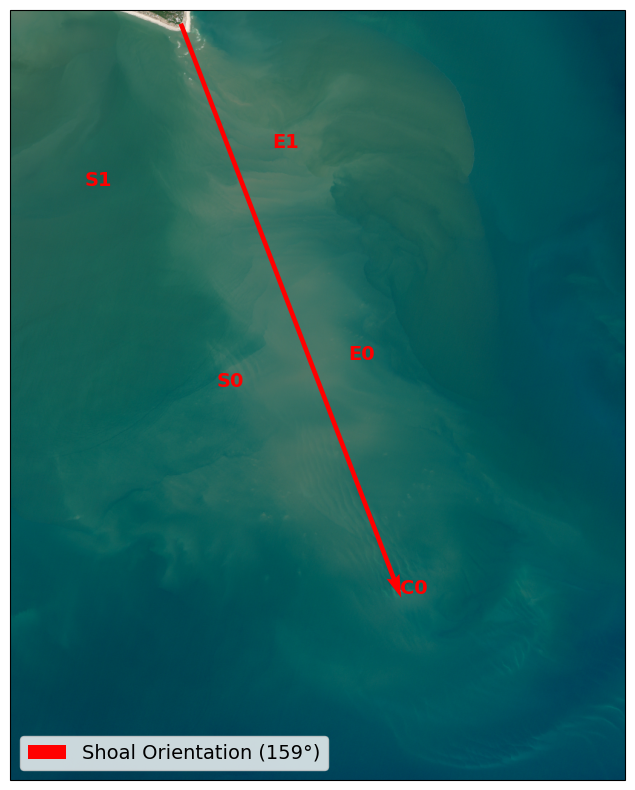

In [7]:
#Guide plot for orientation of the shoals to go along with the tables.
#Plotter that overlays tidal ellipses from all deployments and landers on top of shoals 
# Convert dep to string to match filename parsing
import rasterio
import cartopy.crs as ccrs
import matplotlib.lines as mlines

filepath = r"z:\deployment_2\2024-11-25_16bitTiff.tiff"
filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}
shoal_bearing = 159
x = 1*np.sin(np.deg2rad(shoal_bearing))
y = 1*np.cos(np.deg2rad(shoal_bearing))
plt.quiver(-77.962000, 33.845000, x, y, color='red', scale=1, label='Shoal Orientation (159°)')

for sensor, (lon, lat) in lander_coords.items():
    ax.text(lon, lat, sensor, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')
    
plt.legend(loc='lower left')

['Z:/deployment_1/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_1/BulkStats\\S0_103080', 'Z:/deployment_1/BulkStats\\S1_101418']
Processing S0...
Processing S1...
['Z:/deployment_2/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_2/BulkStats\\S0_103080', 'Z:/deployment_2/BulkStats\\S1_101418']
Processing S0...
Processing S1...
['Z:/deployment_3/BulkStats\\E0_103080']
Processing E0...
['Z:/deployment_3/BulkStats\\C0_103071']
Processing C0...
['Z:/deployment_3/BulkStats\\S0_101418']
Processing S0...
['Z:/deployment_4/BulkStats\\E1_103071']
Processing E1...
[]
['Z:/deployment_4/BulkStats\\S1_103080']
Processing S1...
[]
['Z:/deployment_5/BulkStats\\C0_107730']
Processing C0...
['Z:/deployment_5/BulkStats\\S1_101481']
Processing S1...


Text(0.5, 1.0, 'Tidal Ellipses on FPS for All Deployments')

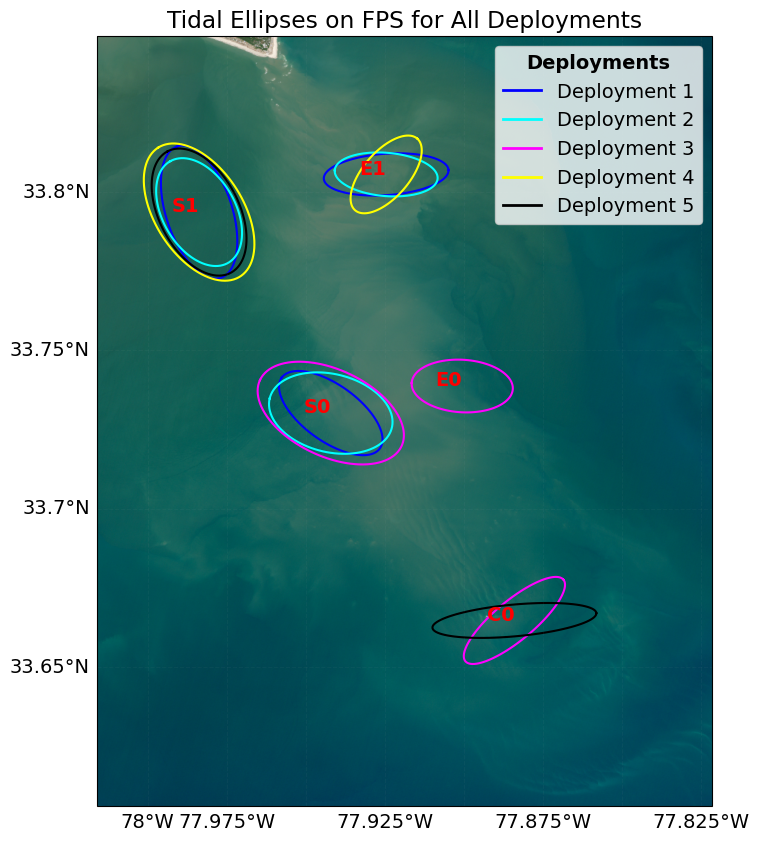

In [ ]:
#Plotter that overlays tidal ellipses from all deployments and landers on top of shoals 
# Convert dep to string to match filename parsing

filepath = r"z:\deployment_2\2024-11-25_16bitTiff.tiff"
filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

deployment_colors = {
    1: 'blue',
    2: 'cyan',
    3: 'magenta',
    4: 'yellow',
    5: 'black',
}

for dep in deployment_num:
    dep_color = deployment_colors.get(dep, 'white')
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        print(sensor_ids)
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            data = globals()[f"waves_{sensor_location}_{dep}"]
            print(f"Processing {sensor_location}...")


            # Get coords from dictionary, default to S0 if not found
            sensor = str(sensor_location)
            lon, lat = lander_coords.get(sensor, lander_coords["S0"])

            a = data['MajorTidalAxis'][0] * 0.01
            b = data['MinorTidalAxis'][0] * 0.01
            theta = np.radians(data['Theta'][0])

            t = np.linspace(0, 2 * np.pi, 100)

            x = a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
            y = a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)

            # Shift the calculated velocities to the sensor's geographic coordinates
            scale_factor = 10
            ellipse_lon = lon + (x * scale_factor)
            ellipse_lat = lat + (y * scale_factor)

            # Plot the ellipse
            ax.plot(ellipse_lon, ellipse_lat,color=dep_color, label=f"{sensor_location} - Deployment {dep}")

            # Add a label for the lander
            if dep == 1:  # Only label for the first deployment to avoid clutter
                ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

# Gridlines and Labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
gl.top_labels = False
gl.right_labels = False

#Add labels for E0 and C0
lon, lat = lander_coords.get("E0", (lander_coords["S0"]))
ax.text(lon, lat, "E0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')
lon, lat = lander_coords.get("C0", (lander_coords["S0"]))
ax.text(lon, lat, "C0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

legend_elements = []

# Loop through your color dictionary and create a legend entry for each one
for dep_num, color in deployment_colors.items():
    line = mlines.Line2D([], [], color=color, linewidth=2, label=f'Deployment {dep_num}')
    legend_elements.append(line)

# Add the legend to the map with a nice title
ax.legend(handles=legend_elements, loc='upper right', title="Deployments", 
          title_fontproperties={'weight': 'bold'})

plt.title(f"Tidal Ellipses on FPS for All Deployments")

In [9]:
#Look at Backscatter variability
#First calculate a bunch of representative statistics for each sensor and deployment, then make a table comparing them.
from spectral_sediment import despiker 

for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0, S1, E1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")  # Extract S0 or S1
            print(f"Processing {sensor_location} for backscatter variability...")
            waves = globals()[f"waves_{sensor_location[0]}_{dep}"]
            file_name = "Echo1avg" if "Echo1avg" in waves else "Vertavg"
            echoavg = waves[file_name]
            if file_name == "Echo1avg":
                echoavg = despiker(despiker(echoavg, fs=2, lam=3)[0],fs=2, lam=2)[0]  # Despike according to goring and nikora
            if file_name == "Vertavg":
                echoavg = despiker(despiker(echoavg, fs=4, lam=3)[0],fs=4, lam=2)[0]  # Despike according to goring and nikora
            # Calculate variability
            mean_echo = np.mean(echoavg)
            std_echo = np.std(echoavg)
            waves['Echo_Variability'] = std_echo / mean_echo 
            




Processing ['E1', '103071'] for backscatter variability...
Processing ['S0', '103080'] for backscatter variability...
Processing ['S1', '101418'] for backscatter variability...
Processing ['E1', '103071'] for backscatter variability...
Processing ['S0', '103080'] for backscatter variability...
Processing ['S1', '101418'] for backscatter variability...
Processing ['E0', '103080'] for backscatter variability...
Processing ['C0', '103071'] for backscatter variability...
Processing ['S0', '101418'] for backscatter variability...
Processing ['E1', '103071'] for backscatter variability...
Processing ['S1', '103080'] for backscatter variability...
Processing ['C0', '107730'] for backscatter variability...
Processing ['S1', '101481'] for backscatter variability...


In [10]:
variability = [["Variability", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
             ['S0', waves_S0_1['Echo_Variability'], waves_S0_2['Echo_Variability'], waves_S0_3['Echo_Variability'], 'N/A'],
             ['S1', waves_S1_1['Echo_Variability'], waves_S1_2['Echo_Variability'], 'N/A', waves_S1_4['Echo_Variability'], waves_S1_5['Echo_Variability']],
             ['E0',None, None, waves_E0_3['Echo_Variability'],],
             ['E1',waves_E1_1['Echo_Variability'], waves_E1_2['Echo_Variability'],None, waves_E1_4['Echo_Variability'], None],
             ['C0', None, None, waves_C0_3['Echo_Variability'],None,waves_C0_5['Echo_Variability']]]

print(tabulate.tabulate(variability, headers="firstrow", tablefmt="double_grid", missingval="N/A"))

╔═══════════════╦═════════════════╦═════════════════╦══════════════════════╦═════════════════════╦═════════════════╗
║ Variability   ║   Summer-->Fall ║   Fall-->Winter ║ Winter-->Spring      ║ Spring-->Summer     ║   Summer-->Fall ║
╠═══════════════╬═════════════════╬═════════════════╬══════════════════════╬═════════════════════╬═════════════════╣
║ S0            ║        0.311597 ║        0.611079 ║ 0.051536194012133475 ║ N/A                 ║     N/A         ║
╠═══════════════╬═════════════════╬═════════════════╬══════════════════════╬═════════════════════╬═════════════════╣
║ S1            ║        0.173866 ║        0.501512 ║ N/A                  ║ 0.1821681215245337  ║       0.0906845 ║
╠═══════════════╬═════════════════╬═════════════════╬══════════════════════╬═════════════════════╬═════════════════╣
║ E0            ║      N/A        ║      N/A        ║ 0.06267692410276324  ║ N/A                 ║     N/A         ║
╠═══════════════╬═════════════════╬═════════════════╬═══════════

In [16]:
print(np.shape(waves_S1_1['StokesDriftMagnitude']), np.shape(waves_S1_1['SignificantWaveHeight']))

(696, 145) (696, 1)


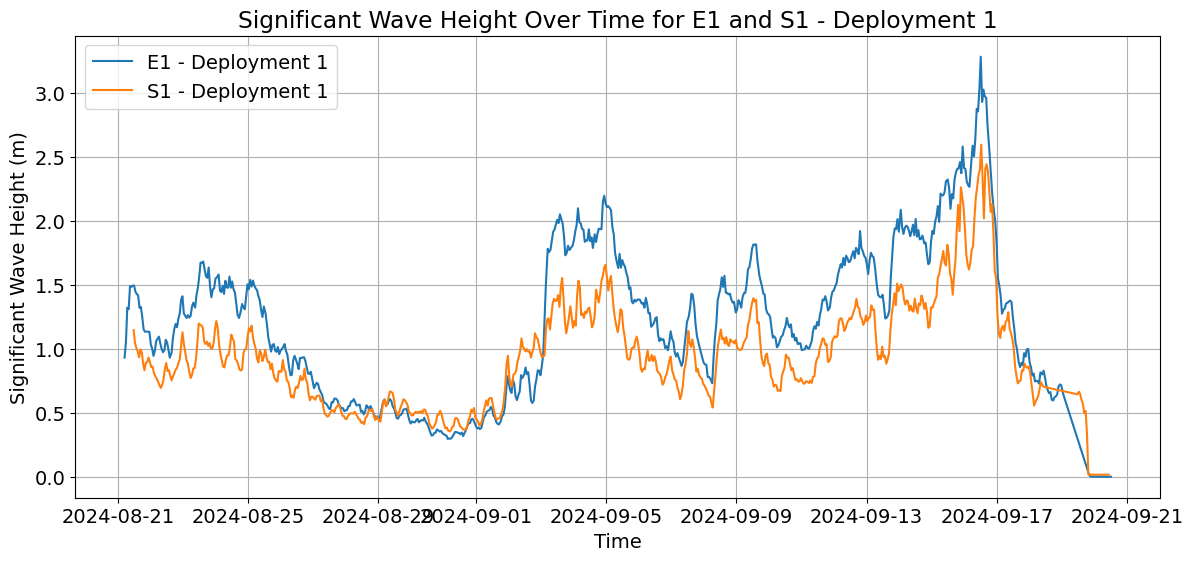

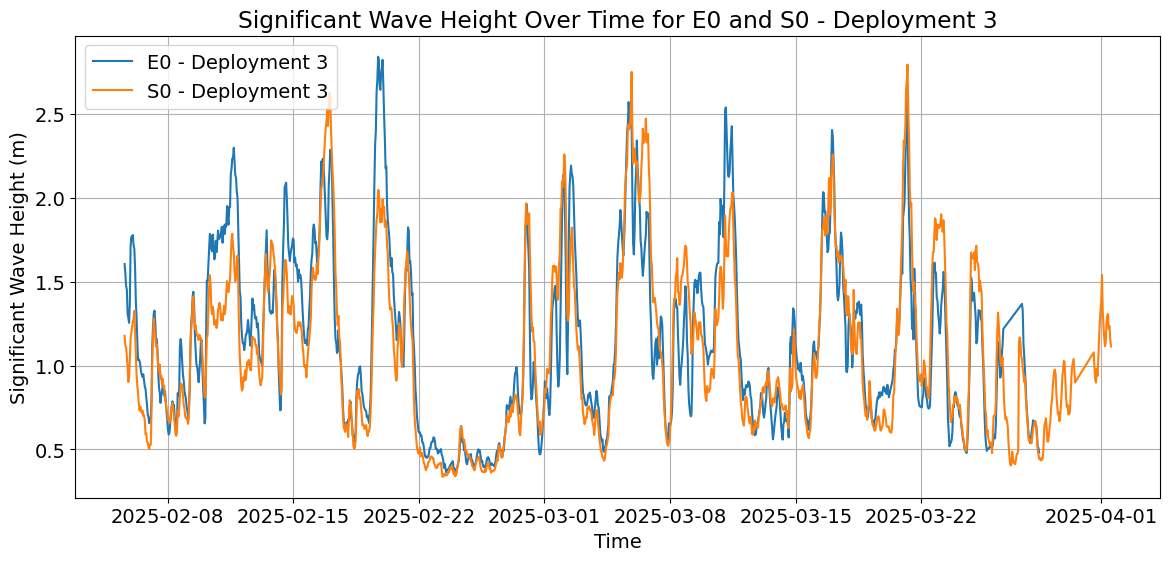

In [11]:
#Plot for echosounder amplitudes
plt.figure(figsize=(14, 6))
plt.plot(waves_E1_1['Time'], waves_E1_1['SignificantWaveHeight'], label='E1 - Deployment 1')
plt.plot(waves_S1_1['Time'], waves_S1_1['SignificantWaveHeight'], label='S1 - Deployment 1')
plt.xlabel('Time')
plt.ylabel('Significant Wave Height (m)')
plt.title('Significant Wave Height Over Time for E1 and S1 - Deployment 1')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(waves_E0_3['Time'], waves_E0_3['SignificantWaveHeight'], label='E0 - Deployment 3')
plt.plot(waves_S0_3['Time'], waves_S0_3['SignificantWaveHeight'], label='S0 - Deployment 3')
plt.xlabel('Time')
plt.ylabel('Significant Wave Height (m)')
plt.title('Significant Wave Height Over Time for E0 and S0 - Deployment 3')
plt.grid(True)
plt.legend()
plt.show()